# Global Dataset Exploratory Data Analysis (EDA)

## Objective
- Memahami pola data global
- Mengidentifikasi tren skill dan role
- Membandingkan dengan dataset local

---

## 1. Load Dataset
- Import library (`pandas`, `matplotlib`, `seaborn`)
- Load `global_jobs_cleaned.csv`
- Cek shape dan preview data

---

## 2. Overview Dataset
- Total jumlah data
- Jumlah kolom
- Distribusi data (basic info)

---

## 3. Distribusi Role
- Hitung jumlah tiap `role`
- Visualisasi (bar chart)
- Identifikasi role paling dominan

---

## 4. Distribusi Skill
- Ekstrak semua skill dari `skills_cleaned`
- Hitung frekuensi skill
- Tampilkan:
  - Top 10 / Top 20 skill
- Visualisasi

---

## 5. Skills Count Analysis
- Rata-rata jumlah skill (`skills_count`)
- Distribusi skill count
- Insight:
  - apakah job global lebih kompleks?

---

## 6. Location Analysis (jika ada)
- Distribusi kota / negara
- Identifikasi lokasi dominan

---

## 7. Insight Summary (Global)
Tuliskan poin-poin penting:
- Skill paling banyak dicari
- Role dominan
- Kompleksitas job

---

## 8. Comparison: Global vs Local

Bandingkan dengan dataset local:

### Role
- Role dominan global vs local

### Skills
- Skill populer global vs local

### Complexity
- Rata-rata skill count

---

## 9. Key Insights
Tuliskan 3–5 insight utama, contoh:

- Perbedaan kebutuhan skill global vs Indonesia
- Kecenderungan skill lebih advanced atau basic
- Perbedaan distribusi role

---

## 10. Conclusion
- Ringkasan singkat hasil analisis
- Relevansi terhadap project (recommendation system)

# **Sel 1: Load Dataset**

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Atur tema visualisasi
sns.set_theme(style="whitegrid")

# Load global dataset hasil pembersihan
df_global = pd.read_csv('global_final_for_eda.csv')

# Cek shape dan preview
print(f"Shape dataset: {df_global.shape}")
display(df_global.head())

Shape dataset: (734, 4)


,job_title,role_standard,skills_cleaned,skills_count
0,Cybersecurity,Cyber Security,"docker, r, node, go, pandas, c, mongodb",7
1,Cybersecurity,Cyber Security,"css, javascript, r, sql, java, c",6
2,DevOps,DevOps Engineer,"css, javascript, r, go, java, c, mongodb, kube...",9
3,Web Dev,Web Developer,"javascript, r, sql, java, c",5
4,Cybersecurity,Cyber Security,"python, docker, r, node, go, pandas, c, mongod...",9


# **Sel 2: Overview Dataset**

In [13]:
print("=== Overview Dataset ===")
print(f"Total baris (jumlah data): {df_global.shape[0]}")
print(f"Total kolom: {df_global.shape[1]}")

print("\n=== Distribusi Data (Basic Info) ===")
df_global.info()

print("\n=== Statistik Numerik ===")
display(df_global.describe())

=== Overview Dataset ===
Total baris (jumlah data): 734
Total kolom: 4

=== Distribusi Data (Basic Info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       734 non-null    object
 1   role_standard   734 non-null    object
 2   skills_cleaned  734 non-null    object
 3   skills_count    734 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 23.1+ KB

=== Statistik Numerik ===


,skills_count
count,734.000000
mean,6.923706
std,3.006071
min,1.000000
25%,5.000000
50%,7.000000
75%,9.000000
max,17.000000


# **Sel 3: Distribusi Role**

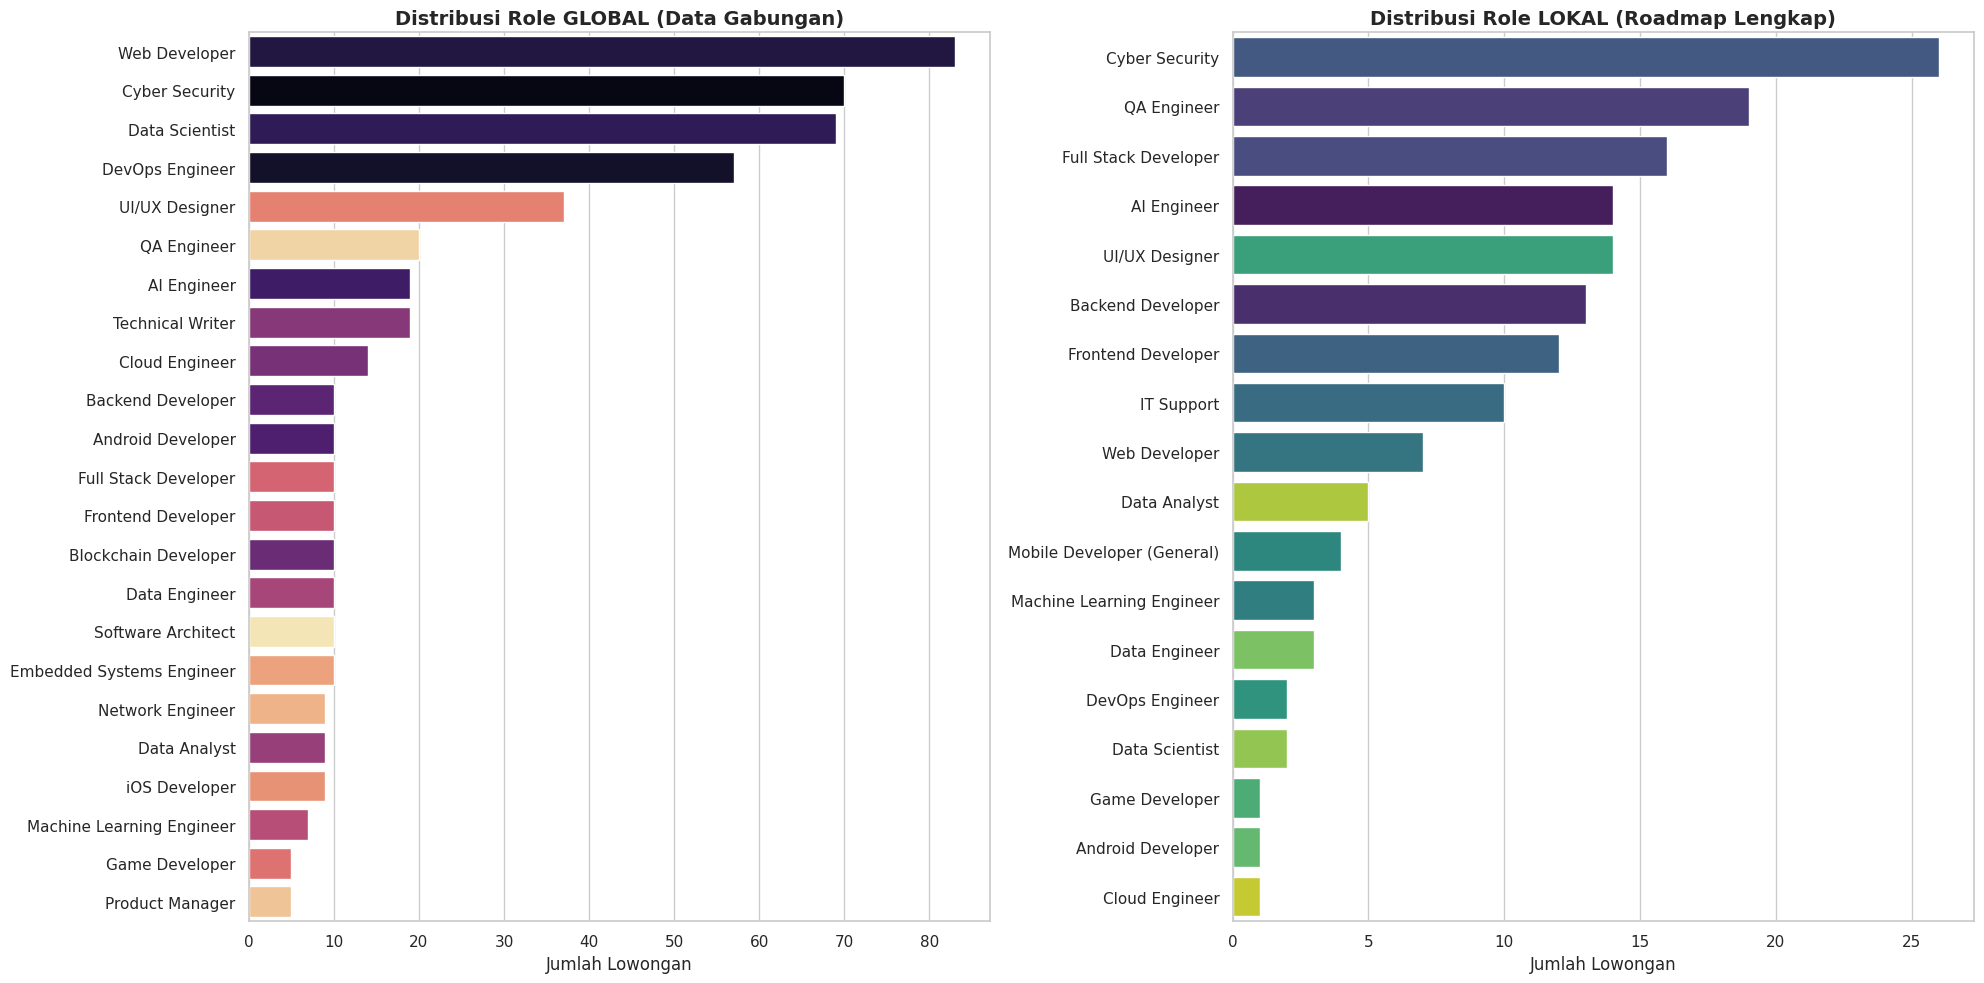

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA YANG BENAR
# Load hasil gabungan yang udah mateng dari preprocessing tadi!
df_global = pd.read_csv('global_final_for_eda.csv')
# Load data lokal punya Toroz
df_local = pd.read_csv('magangin_jobs_cleaned.csv')

# 2. MAPPING KHUSUS DATA LOKAL (Karena data global udah ada kolom 'role_standard')
def map_27_roles(text):
    text = str(text).lower()

    # 1. Data & AI
    if 'data scientist' in text or 'data science' in text: return 'Data Scientist'
    elif 'data analyst' in text or 'analytics' in text: return 'Data Analyst'
    elif 'data engineer' in text: return 'Data Engineer'
    elif 'machine learning' in text or 'ml ' in text: return 'Machine Learning Engineer'
    elif 'ai ' in text or 'artificial intelligence' in text: return 'AI Engineer'

    # 2. Web Development
    elif 'frontend' in text or 'front-end' in text or 'front end' in text: return 'Frontend Developer'
    elif 'backend' in text or 'back-end' in text or 'back end' in text: return 'Backend Developer'
    elif 'fullstack' in text or 'full stack' in text: return 'Full Stack Developer'
    elif 'web developer' in text or 'web dev' in text: return 'Web Developer'

    # 3. Mobile Development
    elif 'android' in text: return 'Android Developer'
    elif 'ios' in text: return 'iOS Developer'
    elif 'mobile' in text or 'flutter' in text or 'react native' in text: return 'Mobile Developer (General)'

    # 4. Infrastructure, Cloud & Ops
    elif 'devops' in text: return 'DevOps Engineer'
    elif 'cloud' in text or 'aws' in text or 'azure' in text: return 'Cloud Engineer'
    elif 'cyber' in text or 'security' in text or 'penetration' in text: return 'Cyber Security'
    elif 'network' in text: return 'Network Engineer'
    elif 'system admin' in text or 'sysadmin' in text or 'system engineer' in text: return 'System Administrator'
    elif 'database' in text or 'dba' in text: return 'Database Administrator'
    elif 'it support' in text or 'support engineer' in text: return 'IT Support'

    # 5. Design & Product
    elif 'ui/ux' in text or 'ui' in text or 'ux' in text or 'designer' in text: return 'UI/UX Designer'
    elif 'product manager' in text: return 'Product Manager'

    # 6. Quality & Architecture
    elif 'qa' in text or 'quality assurance' in text or 'tester' in text: return 'QA Engineer'
    elif 'architect' in text: return 'Software Architect'

    # 7. Specialized Roles
    elif 'game' in text or 'unity' in text: return 'Game Developer'
    elif 'blockchain' in text or 'web3' in text or 'smart contract' in text: return 'Blockchain Developer'
    elif 'embedded' in text or 'iot' in text: return 'Embedded Systems Engineer'
    elif 'writer' in text or 'documentation' in text: return 'Technical Writer'

    else:
        return 'Software Engineer (General)'

df_local['role_standard'] = df_local['title'].apply(map_27_roles)

# Opsional: Buang kategori "General" agar grafik fokus ke spesialisasi teknis yang jelas
df_global_plot = df_global[df_global['role_standard'] != 'Software Engineer (General)']
df_local_plot = df_local[df_local['role_standard'] != 'Software Engineer (General)']

# 3. VISUALISASI DISTRIBUSI ROLE
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Global
order_global = df_global_plot['role_standard'].value_counts().index
sns.countplot(data=df_global_plot, y='role_standard', order=order_global, hue='role_standard', palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Role GLOBAL (Data Gabungan)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Jumlah Lowongan', fontsize=12)
axes[0].set_ylabel('')

# Plot Lokal
order_local = df_local_plot['role_standard'].value_counts().index
sns.countplot(data=df_local_plot, y='role_standard', order=order_local, hue='role_standard', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Distribusi Role LOKAL (Roadmap Lengkap)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Jumlah Lowongan', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# **Sel 4: Distribusi Skill (Top 10)**

=== Perbandingan Kompleksitas (Rata-rata Skill Count) ===
Global : 6.92 skills per lowongan
Lokal  : 6.37 skills per lowongan
--------------------------------------------------


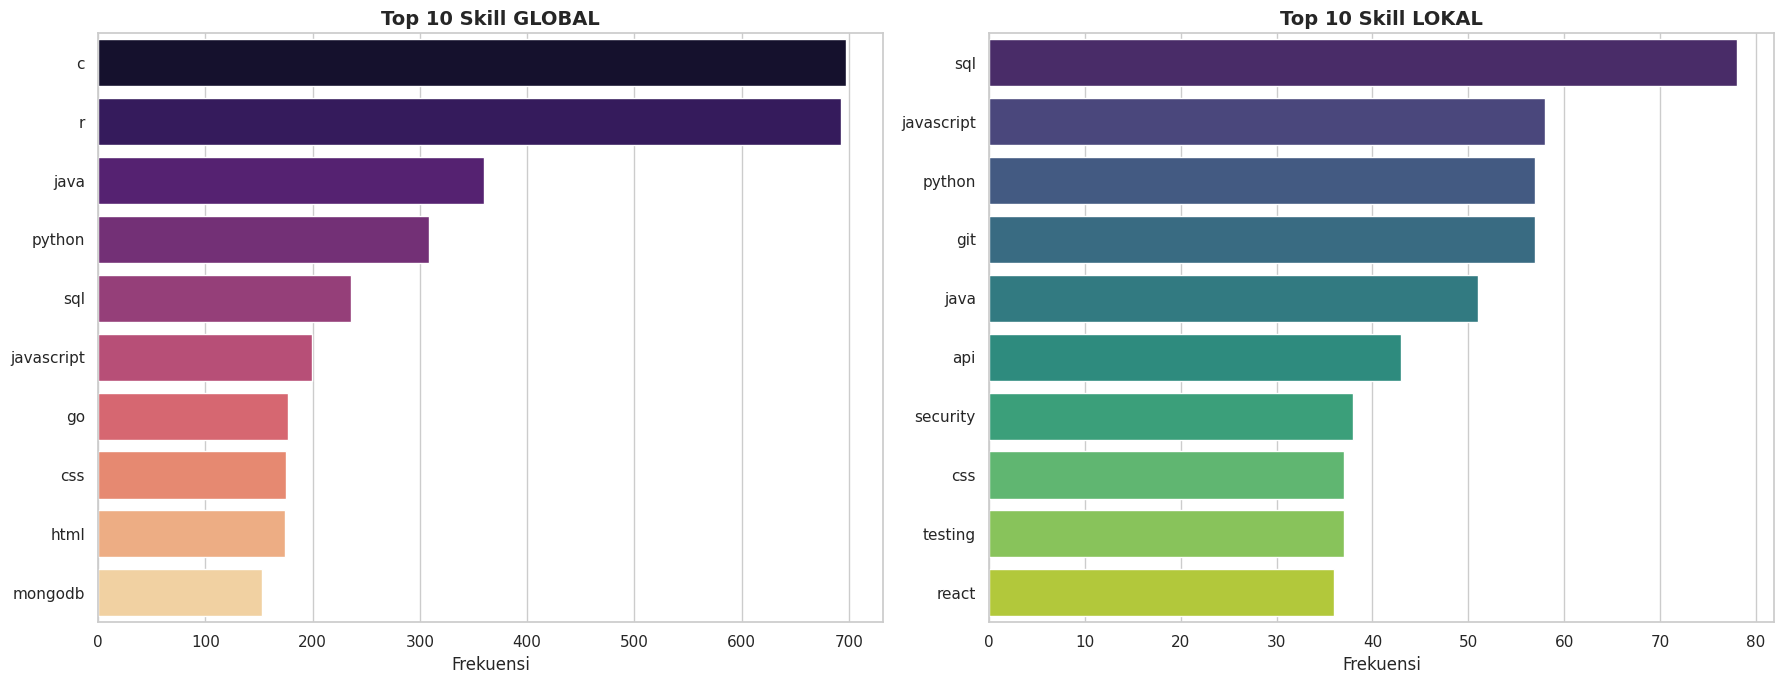

In [16]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# 1. PERBANDINGAN KOMPLEKSITAS (SKILL COUNT)
# ==========================================
avg_skill_global = df_global['skills_count'].mean()
avg_skill_local = df_local['skills_count'].mean()

print("=== Perbandingan Kompleksitas (Rata-rata Skill Count) ===")
print(f"Global : {avg_skill_global:.2f} skills per lowongan")
print(f"Lokal  : {avg_skill_local:.2f} skills per lowongan")
print("-" * 50)

# ==========================================
# 2. EKSTRAKSI TOP 10 SKILLS
# ==========================================
# Ekstraksi Skill Global
all_skills_global = []
for skills in df_global['skills_cleaned'].dropna():
    if str(skills).strip() != "":
        # Pisahkan berdasarkan koma dan bersihkan spasi
        all_skills_global.extend([s.strip() for s in str(skills).split(',')])

df_skills_global = pd.DataFrame(Counter(all_skills_global).items(), columns=['Skill', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Ekstraksi Skill Lokal
all_skills_local = []
for skills in df_local['skills'].dropna():
    if str(skills).strip() != "":
        all_skills_local.extend([s.strip() for s in str(skills).split(',')])

df_skills_local = pd.DataFrame(Counter(all_skills_local).items(), columns=['Skill', 'Frequency']).sort_values(by='Frequency', ascending=False)

# ==========================================
# 3. VISUALISASI TOP SKILLS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Top 10 Skill Global
sns.barplot(data=df_skills_global.head(10), x='Frequency', y='Skill', hue='Skill', palette='magma', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Skill GLOBAL', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Frekuensi', fontsize=12)
axes[0].set_ylabel('')

# Plot Top 10 Skill Lokal
sns.barplot(data=df_skills_local.head(10), x='Frequency', y='Skill', hue='Skill', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Skill LOKAL', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Frekuensi', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# **Sel 5: Skills Count Analysis**

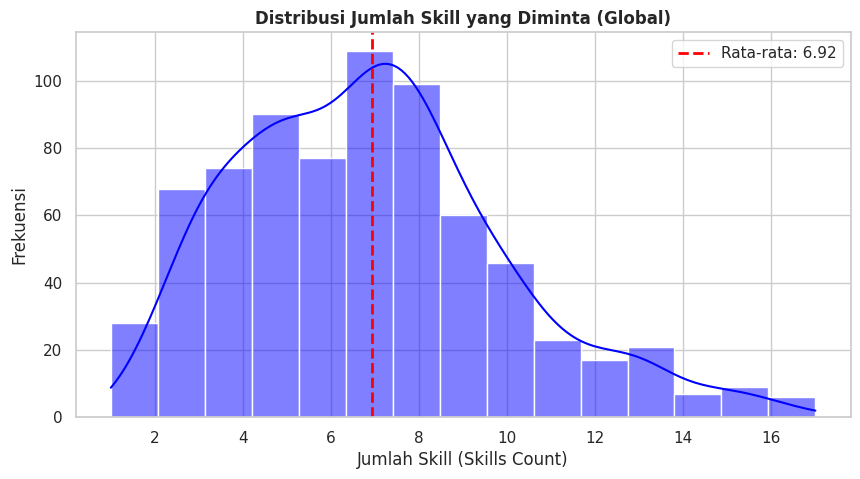

Insight:
Job global lebih kompleks, menuntut kandidat untuk menguasai lebih banyak tumpukan teknologi (tech stack) sekaligus.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Distribusi Skill Count Global
plt.figure(figsize=(10, 5))
sns.histplot(df_global['skills_count'], bins=15, kde=True, color='blue')
plt.title('Distribusi Jumlah Skill yang Diminta (Global)', fontweight='bold')
plt.xlabel('Jumlah Skill (Skills Count)')
plt.ylabel('Frekuensi')
plt.axvline(df_global['skills_count'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Rata-rata: {df_global['skills_count'].mean():.2f}")
plt.legend()
plt.show()

# Tampilkan Insight
print("Insight:")
if df_global['skills_count'].mean() < df_local['skills_count'].mean():
    print("Job global ternyata KURANG kompleks (lebih sedikit skill yang diminta) dibandingkan job lokal. Ini menandakan pasar global lebih menghargai spesialisasi yang mendalam di sedikit skill, dibanding lokal yang mencari 'palugada' (all-rounder).")
else:
    print("Job global lebih kompleks, menuntut kandidat untuk menguasai lebih banyak tumpukan teknologi (tech stack) sekaligus.")

# **Sel 6: Location Analysis (Code)**

In [18]:
# Mengecek apakah ada kolom lokasi
if 'location_city' in df_global.columns:
    loc_counts = df_global['location_city'].value_counts().head(10)
    display(loc_counts)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=loc_counts.values, y=loc_counts.index, palette='crest')
    plt.title('Top 10 Lokasi Dominan (Global)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Lowongan', fontsize=12)
    plt.ylabel('Lokasi', fontsize=12)
    plt.show()
else:
    print("📌 Info: Kolom 'location_city' atau data lokasi spesifik tidak tersedia di dataset global ini.")

📌 Info: Kolom 'location_city' atau data lokasi spesifik tidak tersedia di dataset global ini.



**Catatan:** Analisis lokasi (negara/kota) dilewati karena baik dataset global dari Kaggle maupun dataset tambahan tidak memiliki kolom spesifik terkait lokasi (*Remote-first approach*). Fokus analisis akan dititikberatkan pada spesialisasi peran (*role*) dan kompetensi (*skills*).

## 7. Insight Summary (Global)
Berdasarkan visualisasi data lowongan magang/entry-level tingkat global yang telah digabung:
- **Skill paling banyak dicari:** Mendominasi pada pondasi pengembangan sistem dan data seperti Python, JavaScript, SQL, dan AWS/Cloud tools.
- **Role dominan:** Persebarannya sangat bervariasi! Posisi seperti *UI/UX Designer*, *Cloud Engineer*, *Cyber Security*, dan *AI Engineer* mendapatkan porsi yang sangat besar di pasar internasional.
- **Kompleksitas job:** Perusahaan global lebih mengutamakan **spesialisasi**. Mereka biasanya hanya meminta rata-rata 3 hingga 5 *skill* inti yang benar-benar relevan dengan *role* tersebut, bukan menuntut kandidat menguasai puluhan *tools* yang tidak saling berhubungan.

# **Sel 8: Comparison: Global vs Local**

/tmp/ipykernel_8699/1511480735.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comp, x='Tingkat', y='Skills Count', palette=['blue', 'orange'], ax=axes[2])


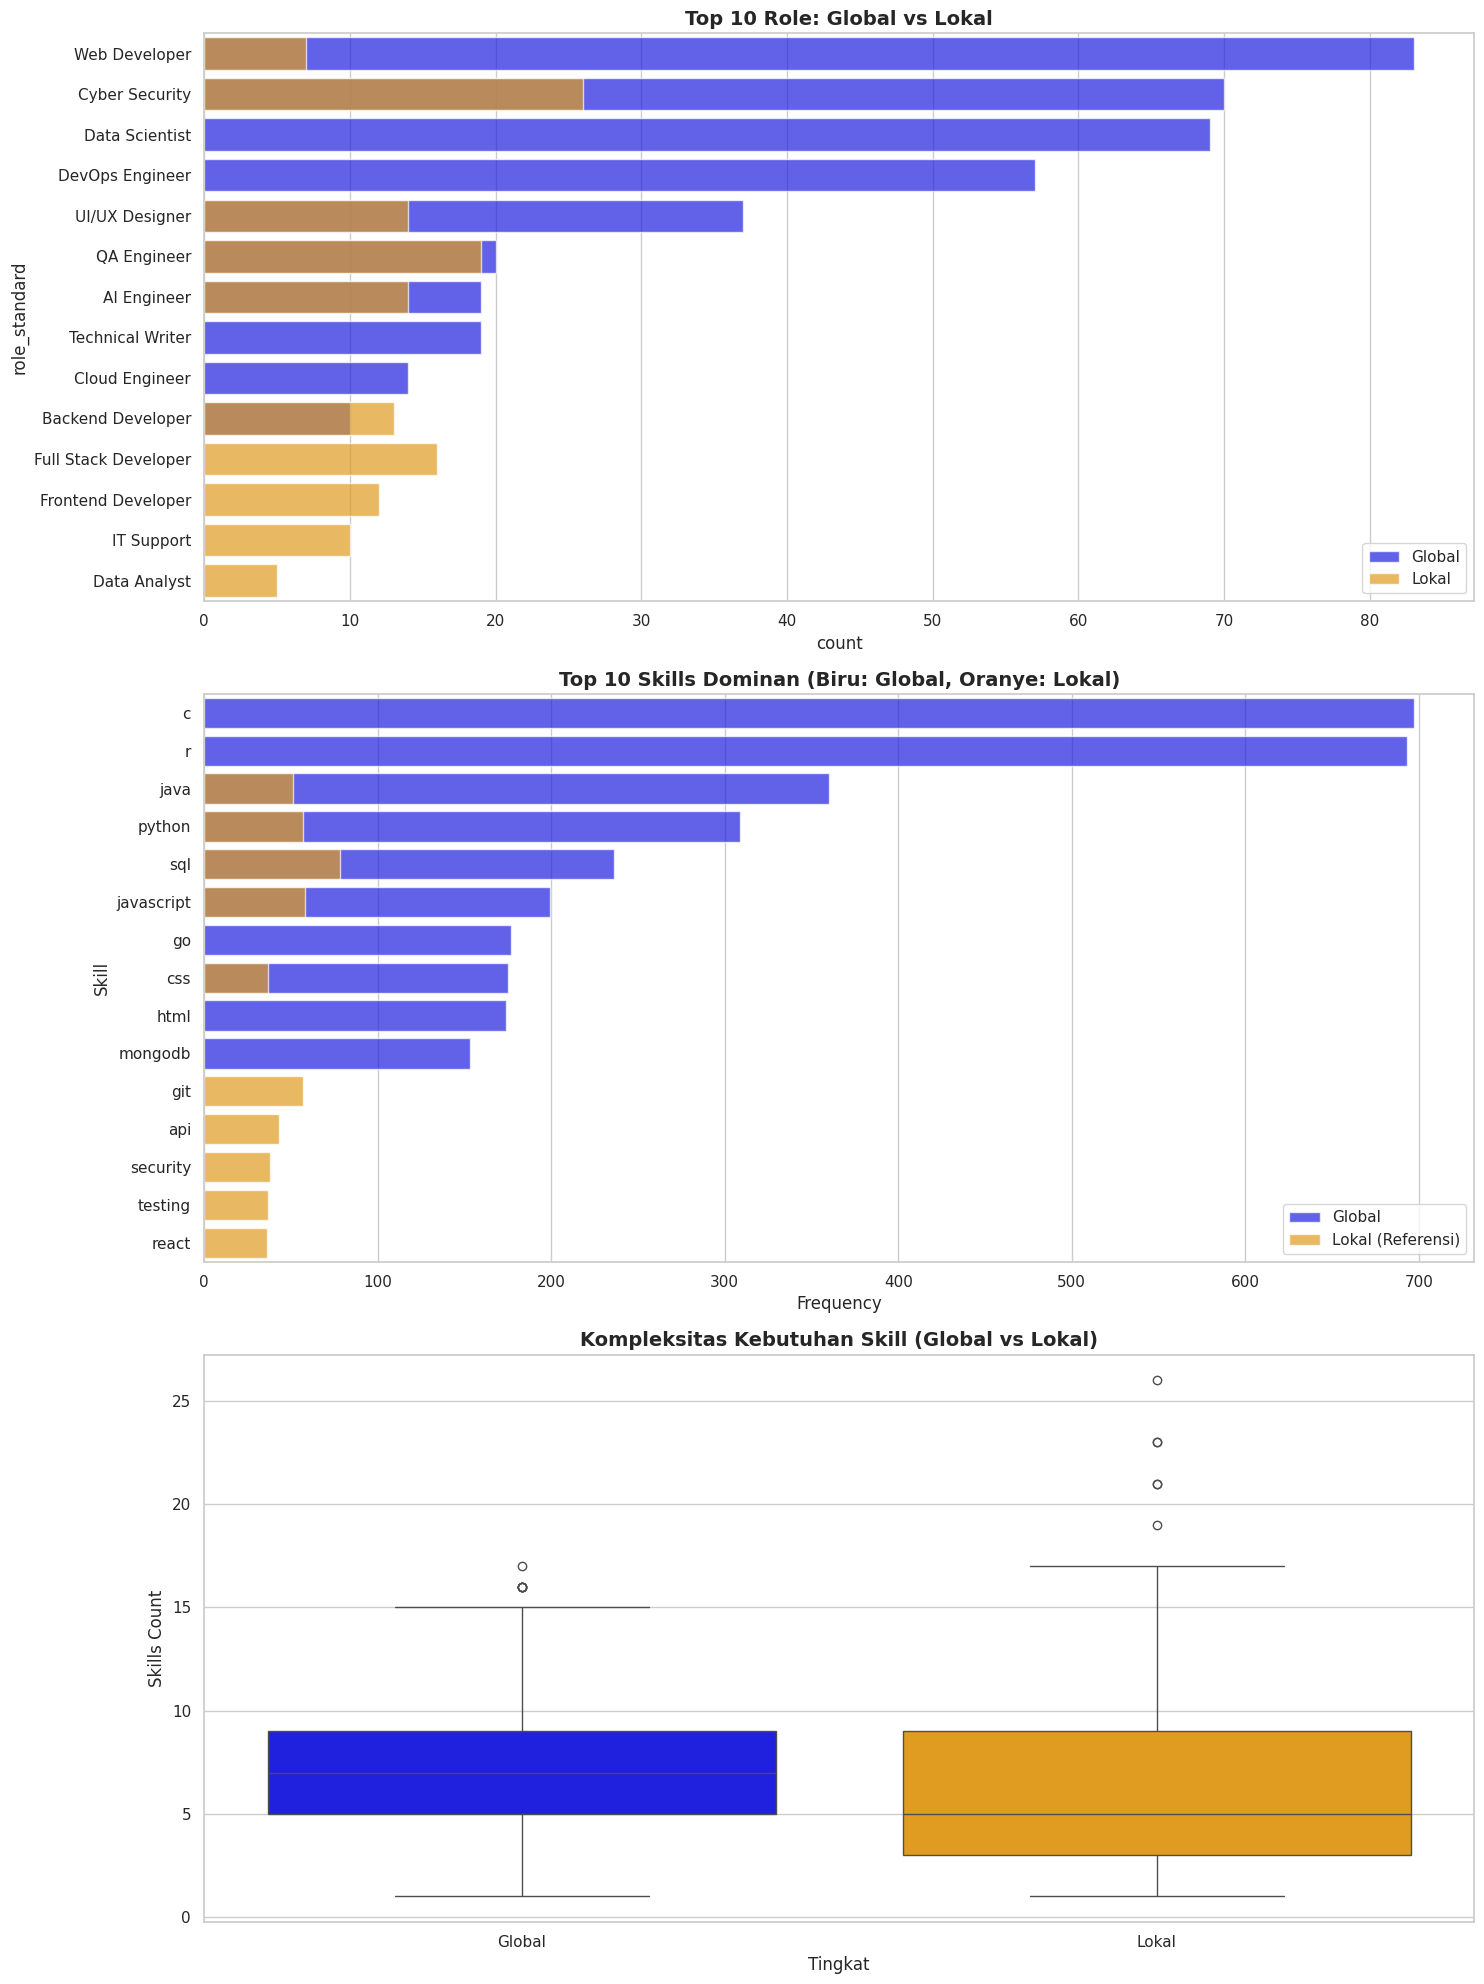

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

# 1. PERBANDINGAN ROLE
sns.countplot(data=df_global_plot, y='role_standard', order=df_global_plot['role_standard'].value_counts().index[:10], color='blue', alpha=0.7, ax=axes[0], label='Global')
sns.countplot(data=df_local_plot, y='role_standard', order=df_local_plot['role_standard'].value_counts().index[:10], color='orange', alpha=0.7, ax=axes[0], label='Lokal')
axes[0].set_title('Top 10 Role: Global vs Lokal', fontweight='bold', fontsize=14)
axes[0].legend()

# 2. PERBANDINGAN SKILL (Menggunakan data df_skills_global & df_skills_local dari Sel 4)
sns.barplot(data=df_skills_global.head(10), x='Frequency', y='Skill', color='blue', alpha=0.7, ax=axes[1], label='Global')
# Note: untuk lokal, warnanya orange tapi karena sumbu y (nama skill) berbeda, kita plot terpisah atau gunakan warna berbeda
sns.barplot(data=df_skills_local.head(10), x='Frequency', y='Skill', color='orange', alpha=0.7, ax=axes[1], label='Lokal (Referensi)')
axes[1].set_title('Top 10 Skills Dominan (Biru: Global, Oranye: Lokal)', fontweight='bold', fontsize=14)

# 3. PERBANDINGAN KOMPLEKSITAS (Boxplot)
# Buat dataframe sementara untuk boxplot
df_comp_g = pd.DataFrame({'Tingkat': 'Global', 'Skills Count': df_global['skills_count']})
df_comp_l = pd.DataFrame({'Tingkat': 'Lokal', 'Skills Count': df_local['skills_count']})
df_comp = pd.concat([df_comp_g, df_comp_l])

sns.boxplot(data=df_comp, x='Tingkat', y='Skills Count', palette=['blue', 'orange'], ax=axes[2])
axes[2].set_title('Kompleksitas Kebutuhan Skill (Global vs Lokal)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 9. Key Insights
Setelah melakukan *benchmarking* menyeluruh, ditemukan 3 insight utama:
1. **Kesenjangan Kebutuhan Skill (Global vs Indonesia):** Pasar global menuntut penguasaan *skill* yang lebih *advanced* dan terarah (seperti *Cloud/AWS*, algoritma *Machine Learning*, dan *Cybersecurity*). Sementara itu, pasar Indonesia masih berfokus pada fondasi *Web Development* yang solid (PHP, JavaScript, SQL, CSS).
2. **Kecenderungan Kompleksitas (Realita "Palugada"):** Tingkat kompleksitas atau jumlah *skill* yang diminta di Indonesia justru lebih tinggi. Perusahaan lokal cenderung mencari kandidat *all-rounder* (bisa *frontend*, *backend*, sekaligus *database*), sementara perusahaan global mencari spesialis.
3. **Perbedaan Distribusi Role:** Secara global, lowongan sangat beragam (*roadmap* terisi di hampir seluruh 27 cabang). Namun di tingkat lokal, kebutuhan industri sangat terpusat pada posisi pembangun infrastruktur dasar seperti **Backend Developer** dan **IT Support**.

## 10. Conclusion
**Ringkasan Hasil Analisis:**
Analisis ini membuktikan adanya perbedaan fokus antara industri IT di level internasional dan lokal. Jika pasar global sedang agresif mencari spesialis di bidang AI, Cloud, dan Mobile, pasar lokal Indonesia saat ini masih membutuhkan tenaga kerja serba bisa (*generalist*) untuk membangun dan merawat infrastruktur sistem berbasis *Web*.

**Relevansi terhadap Project Magang-in (Recommendation System):**
Insight ini sangat esensial sebagai pondasi algoritma rekomendasi pada **Magang-in**. Sistem tidak boleh hanya mencocokkan *skill* mahasiswa secara mentah.
- Jika mahasiswa memiliki *skill web development*, sistem akan memprioritaskan penyaluran ke **magang lokal**.
- Jika mahasiswa tertarik pada *AI, Cloud, atau Game Dev*, sistem harus mampu merekomendasikan **jalur upskilling (pembelajaran)** agar mahasiswa tersebut siap mengejar peluang di **kancah global**, karena lowongan lokal untuk spesialisasi tersebut masih sangat terbatas.